# Testing the Waveform Generator

This noteboook will serve as a quick way of testing if the WaveformModule for 1PAT1R is consistently passing what it should be to the amplitude, summation and trajectory modules.

This is a copy of the original notebook to test on GPU.

In [1]:
!nvidia-smi

No devices were found


In [6]:
import numpy as np
import matplotlib.pyplot as plt

import few
setter = few.get_config_setter()
import os 
print(f'Available backends = {os.getenv('FEW_ENABLED_BACKENDS')}')

from few.waveform import Waveform1PAT1R, FastKerrEccentricEquatorialFlux

Available backends = None


In [7]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R

In [8]:
# --- Generate waveform ---
WF1PAT1R = Waveform1PAT1R()

In [9]:
WF1PAT1R.xp

<module 'numpy' from '/data/leuven/367/vsc36785/miniconda3/envs/emri_env_ddpc/lib/python3.12/site-packages/numpy/__init__.py'>

In [10]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 10      # secondary mass [solar masses]
a  = 5*m2/m1       # primary spin chi1 (dimensionless)
p0 = 7.8     # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.1 # secondary spin

dt = 5.   # time step [s]
T  = 2    # total duration [yr]

In [11]:
h1PAT1R = WF1PAT1R(m1, m2, a, p0, theta, phi, chi2, dt=dt, T=T)

<class 'numpy.ndarray'>


In [6]:
WFKerr0PA = FastKerrEccentricEquatorialFlux()

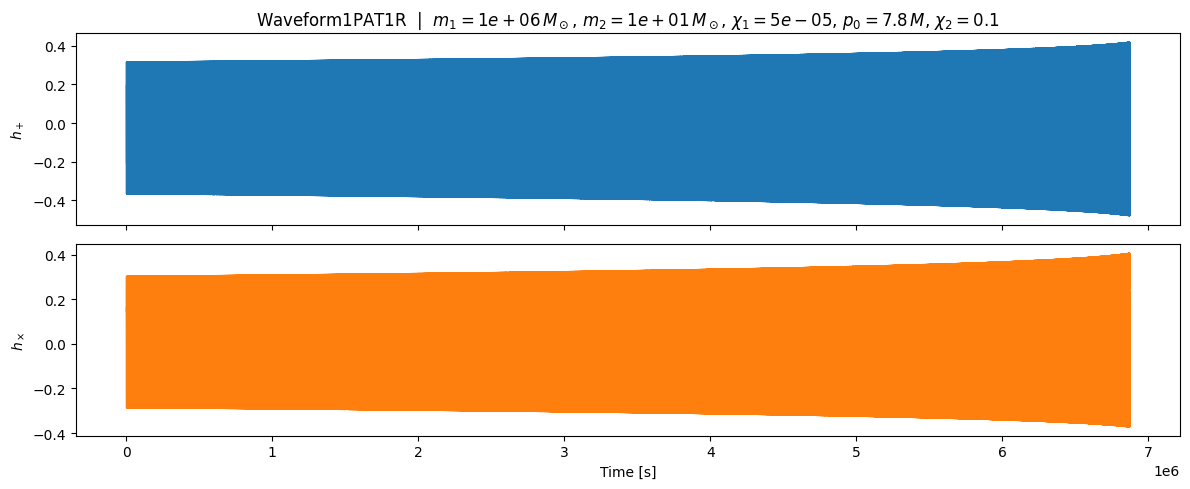

In [10]:
t1PA = np.arange(len(h1PAT1R)) * dt  # time array in seconds

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t1PA, h1PAT1R.real.get() if hasattr(h1PAT1R, 'get') else h1PAT1R.real, lw=0.8)
axes[0].set_ylabel(r"$h_+$")
axes[0].set_title(
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2:.0e}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

axes[1].plot(t1PA, -h1PAT1R.imag.get() if hasattr(h1PAT1R, 'get') else -h1PAT1R.imag, lw=0.8, color="C1")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

In [ ]:
# --- Generate comparison waveform ---
hKerr = WFKerr0PA(m1, m2, a, p0, 0, 1,theta, phi, dt=dt, T=T)

In [ ]:
print(type(hKerr))

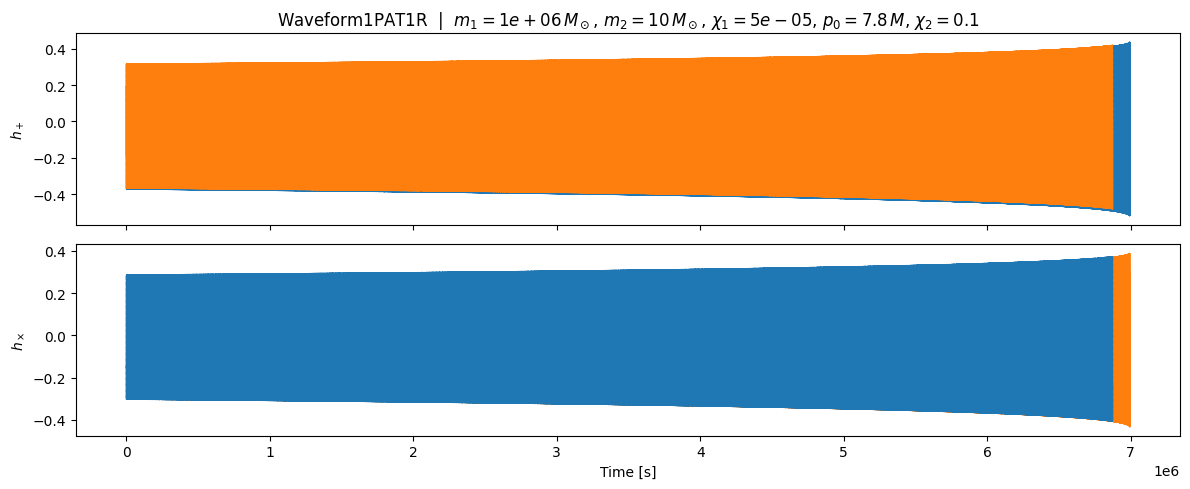

In [29]:
tKerr = np.arange(len(hKerr)) * dt  # time array in seconds
# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(tKerr, hKerr.real.get(), lw=0.8)
axes[0].plot(t1PA, h1PAT1R.real.get(), lw=0.8, ls="--", color="C1")
axes[0].set_ylabel(r"$h_+$")
axes[0].set_title(
    rf"Waveform1PAT1R  |  $m_1={m1:.0e}\,M_\odot$, $m_2={m2}\,M_\odot$, "
    rf"$\chi_1={a}$, $p_0={p0}\,M$, $\chi_2={chi2}$"
)

axes[1].plot(tKerr, hKerr.imag.get(), lw=0.8, color="C1")
axes[1].plot(t1PA, h1PAT1R.imag.get(), lw=0.8, ls="--", color="C0")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()

In [30]:
from lisaconstants import ASTRONOMICAL_YEAR


In [12]:
7e6/ASTRONOMICAL_YEAR

0.22181275050814456

In [23]:
# get difference in plunge time
t1PA_plunge = t1PA[-1]
t0PA_plunge = tKerr[-1]
print(f'Difference in plunge time: {(t0PA_plunge - t1PA_plunge)/3600} hours')

Difference in plunge time: 33.30833333333333 hours


In [13]:
# --- Define Parameters ---
m1 = 1e6       # primary mass [solar masses]
m2 = 10      # secondary mass [solar masses]
a  = 0.0       # primary spin chi1 (dimensionless)
p0 = 9.5      # initial orbital separation [M]
theta = np.pi / 3.0   # polar viewing angle [rad]
phi   = 0.0           # azimuthal viewing angle [rad]
chi2  = 0.0           # secondary spin

dt = 5.   # time step [s]
T  = 1    # total duration [yr]

In [14]:
from few.trajectory.inspiral import EMRIInspiral

# Note that for this test, I commented out all the 1PA order terms in Trajectory1PAT1R, 
# so this should be equivalent to a 0PA trajectory with the same parameters.
traj1PA = EMRIInspiral(func=Trajectory1PAT1R)

# EMRIInspiral expects: (m1, m2, a, p0, e0, xI, *extra_args, T=, dt=)
#   a    = chi1 (primary spin)
#   e0   = 0.0  (circular)
#   xI   = 1.0  (equatorial prograde)
#   chi2 = first extra arg -> additional_args[0] in Trajectory1PAT1R
t, p, e, xI_traj, Phi_phi, Phi_theta, Phi_r, dM, dchi1 = traj1PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    chi2,     # extra arg -> additional_args[0]
    T=T
)

print(f"Trajectory length: {len(t)} points")
print(f"p: {p[0]:.4f} -> {p[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi[0]:.4f} -> {Phi_phi[-1]:.4f} rad")


Trajectory length: 26 points
p: 9.5000 -> 6.6517 M
Phi_phi: 0.0000 -> 262673.3746 rad


In [15]:
from few.trajectory.ode.flux import KerrEccEqFlux

In [16]:
traj0PA = EMRIInspiral(func=KerrEccEqFlux)


t2, p2, e2, xI_traj, Phi_phi2, Phi_theta2, Phi_r2 = traj0PA(
    m1, m2,
    a,        # chi1 (primary spin)
    p0,
    0.0,      # e0: circular
    1.0,      # xI: equatorial prograde
    T=T,
)

print(f"Trajectory length: {len(t2)} points")
print(f"p: {p2[0]:.4f} -> {p2[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi2[0]:.4f} -> {Phi_phi2[-1]:.4f} rad")

Trajectory length: 26 points
p: 9.5000 -> 6.6514 M
Phi_phi: 0.0000 -> 262674.9311 rad


In [17]:
t[-1]

np.float64(31558149.76354559)

Trajectory length: 26 points
p: 9.5000 -> 6.6517 M
Phi_phi: 0.0000 -> 262673.3746 rad


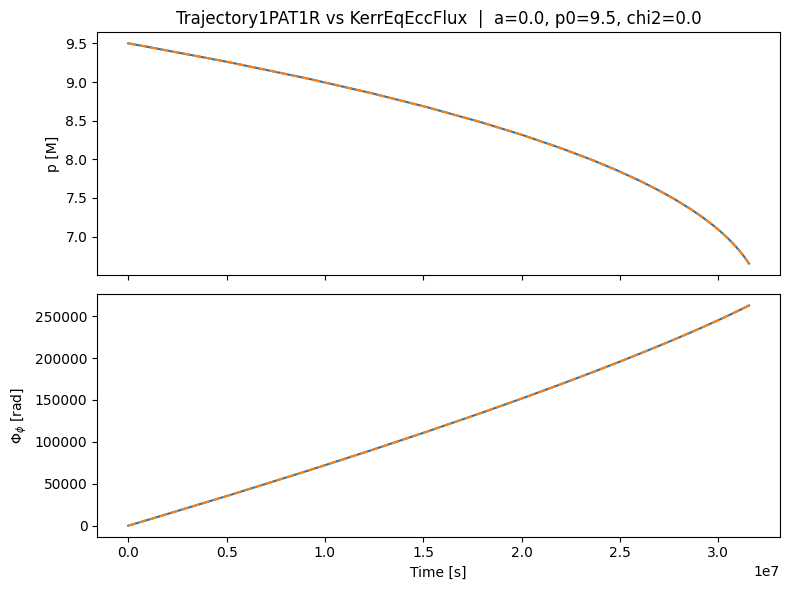

In [18]:
print(f"Trajectory length: {len(t)} points")
print(f"p: {p[0]:.4f} -> {p[-1]:.4f} M")
print(f"Phi_phi: {Phi_phi[0]:.4f} -> {Phi_phi[-1]:.4f} rad")

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t, p)
axes[0].plot(t2, p2, linestyle="--")
axes[0].set_ylabel("p [M]")
axes[0].set_title(f"Trajectory1PAT1R vs KerrEqEccFlux  |  a={a}, p0={p0}, chi2={chi2}")
axes[1].plot(t, Phi_phi)
axes[1].plot(t2, Phi_phi2,linestyle="--")
axes[1].set_ylabel(r"$\Phi_\phi$ [rad]")
axes[1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()


In [19]:
from scipy.interpolate import CubicSpline
pSpline = CubicSpline(t2, p2)
p2Resampled = pSpline(t)


Phi_phiSpline = CubicSpline(t2, Phi_phi2)
Phi_phi2Resampled = Phi_phiSpline(t)


<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3338377/940555635.py:3: SyntaxWarning: invalid escape sequence '\D'
  axes[0].set_ylabel(" \Delta p [M]")


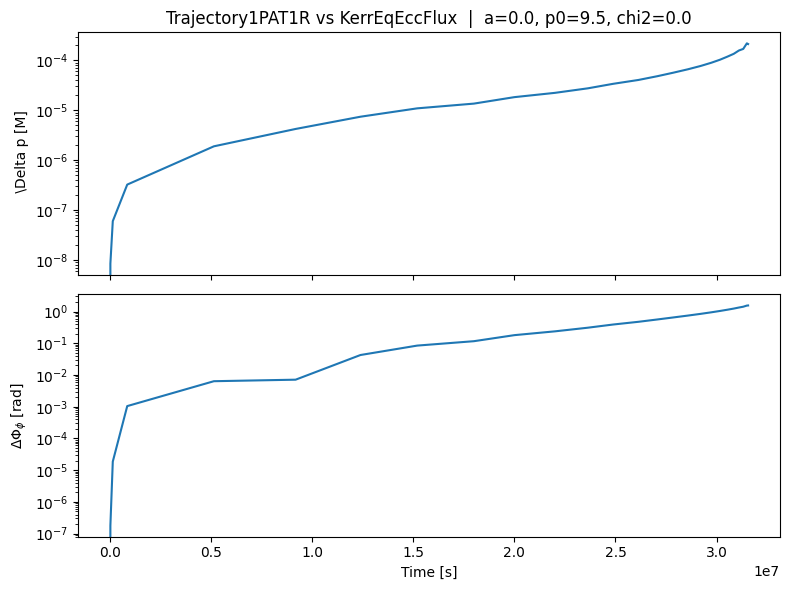

In [20]:

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].plot(t, abs(p2Resampled-p))
axes[0].set_ylabel(" \Delta p [M]")
axes[0].set_yscale("log")
axes[0].set_title(f"Trajectory1PAT1R vs KerrEqEccFlux  |  a={a}, p0={p0}, chi2={chi2}")
axes[1].plot(t, abs(Phi_phi2Resampled-Phi_phi))
axes[1].set_yscale("log")
axes[1].set_ylabel(r"$ \Delta \Phi_\phi$ [rad]")
axes[1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

## Compute mismatch
Compute mismatch with white noise PSD. 
- pad the 1PA waveform up until time series have equal length
- Apply window function to reduce spectral leakage
- FFT waveforms for $h_+, h_\times$
- Compute mismatch $\mathcal(M)(h_1, h_2) = 1 - \frac{\langle h_1|h_2\rangle}{\sqrt{\langle h_1|h_1\rangle \langle h_2|h_2\rangle}}$ with $\langle h_1|h_2\rangle = 4\Re \int_{f_{min}}^{f_{max}} \frac{\tilde{h}_1(f) \tilde{h}_2(f)}{S_n(f)} df$. Boundaries are set to $f_{min} = 1e-5$ Hz, $f_{max} = 1 /(\Delta t)$ with $\Delta t$ the sampling cadence.

In [37]:
from scipy.signal.windows import tukey
import cupy as cp

def white_noise_overlap(h1, h2):
    """Normalised inner product (flat power spectrum)."""
    n = max(len(h1), len(h2))
     # pad with zeros until max length
    h1_padded = cp.pad(h1, (0, n-len(h1)), 'constant', constant_values=(0, 0))
    h2_padded = cp.pad(h2, (0, n-len(h2)), 'constant', constant_values=(0, 0))
    
    window = cp.asarray(tukey(n, alpha=0.01))
    
    h1_f = cp.fft.rfft(h1_padded*window)
    h2_f = cp.fft.rfft(h2_padded*window)
    
    freqs = cp.fft.rfftfreq(n, d=dt)
    
    mask = (freqs > 1e-5) & (freqs < (1 / 2 / dt))
    
    a = h1_f[mask]
    b = h2_f[mask]
    
    na = cp.sqrt(cp.dot(a, a))
    nb = cp.sqrt(cp.dot(b, b))
    if na < 1e-40 or nb < 1e-40:
        return 0.0
    return abs(cp.dot(a, b)) / (na * nb)

In [39]:
# plus polarization
mm_plus = 1- white_noise_overlap(hKerr.real, h1PAT1R.real)
mm_plus

array(0.62036367+0.92573533j)

In [ ]:
# create alias


In [44]:
n = max(len(hKerr.real), len(h1PAT1R.real))
 # pad with zeros until max length
h1PA_padded = cp.pad(h1PAT1R.real, (0, n-len(h1PAT1R.real)), 'constant', constant_values=(0, 0))
h0PA_padded = cp.pad(hKerr.real, (0, n-len(hKerr.real)), 'constant', constant_values=(0, 0))

window = cp.asarray(tukey(n, alpha=0.01))

h1PA_f = cp.fft.rfft(h1PA_padded*window)
h0PA_f = cp.fft.rfft(h0PA_padded*window)

freqs = cp.fft.rfftfreq(n, d=dt)

mask = (freqs > 1e-5) & (freqs < (1 / 2 / dt))

h1PA_f_masked = h1PA_f[mask]
h0PA_f_masked = h0PA_f[mask]

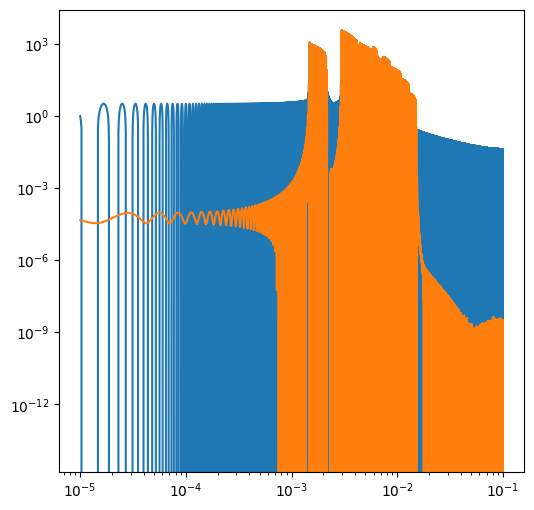

In [45]:
# plot fd waveforms
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.loglog(freqs[mask].get(), h1PA_f_masked.get(), label='1PA')
ax.loglog(freqs[mask].get(), h0PA_f_masked.get(), label='0PA')